# Import modules

In [3]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns

# Loading Datasets 

In [4]:
df_day = pd.read_csv('data/raw/day.csv')
df_hour = pd.read_csv('data/raw/hour.csv')
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


# Exploratory Data Analysis

### Handling Missing Values

In [5]:
print(df_day.isna().sum())
print(df_day.duplicated().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
0


In [6]:
print(df_hour.isna().sum())
print(df_hour.duplicated().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
0


### Visualize

1.Bike demand distribution</br>
2.Hour vs bike demand</br>
3.Weekday vs demand</br>
4.Season vs demand</br>
5.Weather vs demand</br>
6.Temperature vs demand</br>

### Understand

1.When are bikes rented most?</br>
2.Does weather affect rentals?</br>
3.Do weekends differ?</br>

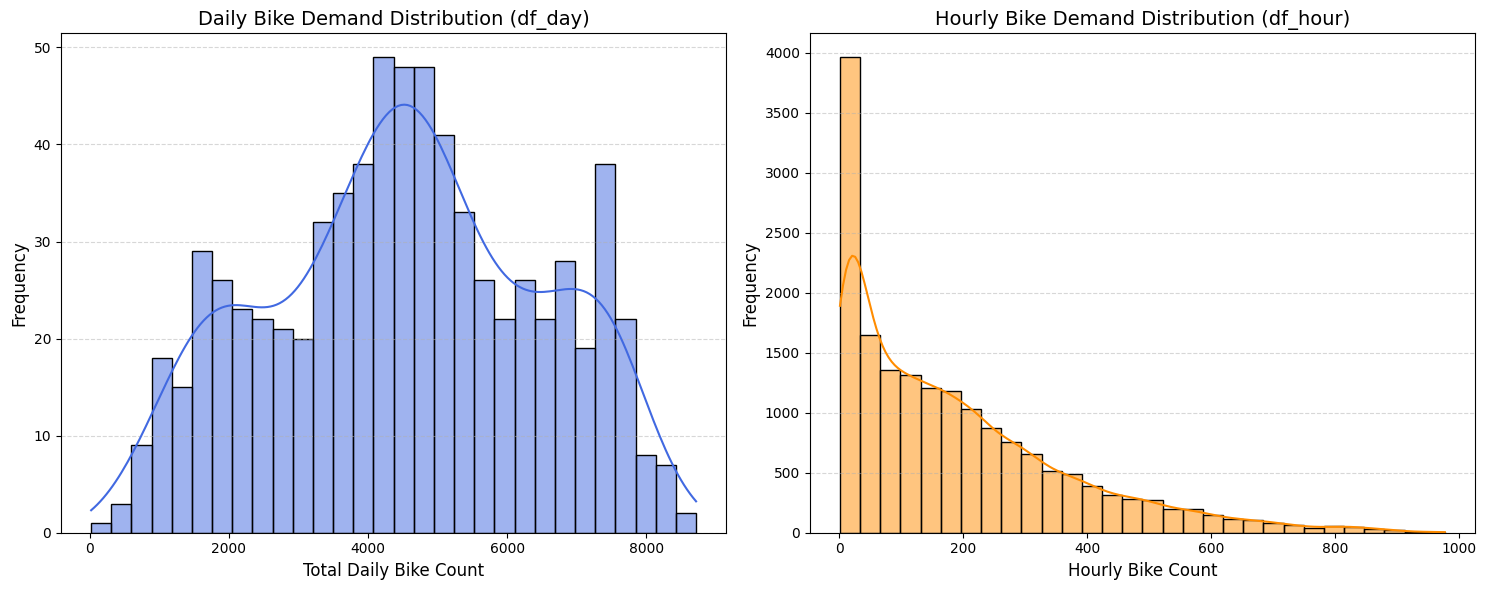

In [7]:
# Bike demand distribution

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Daily Bike Demand Distribution
sns.histplot(data=df_day, x='cnt', kde=True, color='royalblue', ax=axes[0], bins=30)
axes[0].set_title('Daily Bike Demand Distribution (df_day)', fontsize=14)
axes[0].set_xlabel('Total Daily Bike Count', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: Hourly Bike Demand Distribution
sns.histplot(data=df_hour, x='cnt', kde=True, color='darkorange', ax=axes[1], bins=30)
axes[1].set_title('Hourly Bike Demand Distribution (df_hour)', fontsize=14)
axes[1].set_xlabel('Hourly Bike Count', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

#### Overall Insight

1. Daily Bike Demand Distribution (day.csv)
The distribution is approximately bell-shaped (near normal) with a slight skew.
Most days record 4,000–6,000 bike rentals, indicating consistent daily demand.
Very few days have extremely low (<1000) or extremely high (>8000) rentals.
Daily demand is relatively stable because it represents the sum of all hourly rentals.

2. Hourly Bike Demand Distribution (hour.csv)
The distribution is highly right-skewed (positively skewed).
Most hours have low bike rentals (0–200).
High-demand hours (>500 rentals) are rare and form a long right tail.
The skewness reflects the presence of peak commuting hours.

C:\Users\sarth\AppData\Local\Temp\ipykernel_42072\3005640138.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hour, x='hr', y='cnt', palette='viridis')


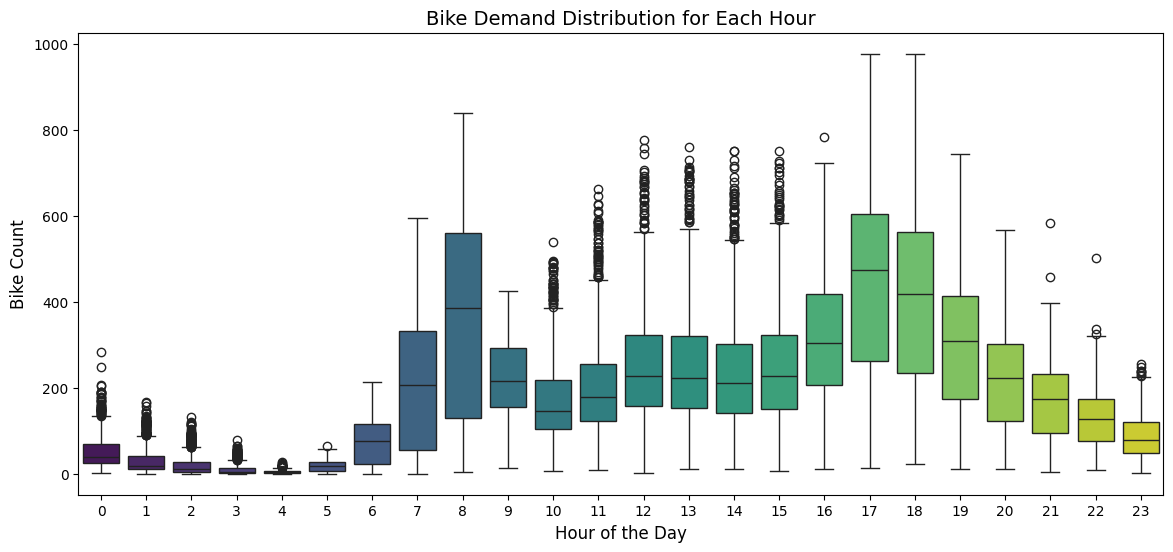

In [8]:
# Bike demand vs hour

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_hour, x='hr', y='cnt', palette='viridis')

plt.title('Bike Demand Distribution for Each Hour', fontsize=14)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Bike Count', fontsize=12)
plt.show()


### Analysis of Bike Demand Distribution by Hour
#### 1. Early Morning (12 AM – 5 AM)

Bike demand is very low.
The median demand is close to zero.
The boxes are narrow, indicating low variability.
A few outliers exist, showing occasional higher demand.

#### 2. Morning Commute (6 AM – 9 AM)

Demand increases sharply after 6 AM.
A significant peak occurs around 8 AM.
The box becomes much taller, indicating higher variability.

#### 3. Midday (10 AM – 3 PM)

Demand remains moderate.
Median bike rentals stay around 180–250.
Several high-value outliers are present.

#### 4. Evening Commute (4 PM – 7 PM)

The highest demand occurs between 5 PM and 6 PM.
These hours have the highest median bike counts.
The widest boxes indicate the greatest variability.
Maximum demand reaches nearly 1000 rentals.

#### 5. Night (8 PM – 11 PM)

Demand gradually declines after 7 PM.
Median bike rentals decrease steadily.
Variability also decreases.


#### Outlier Analysis

The circles above the whiskers represent outliers.
Many outliers are observed between 10 AM and 6 PM.
Few outliers occur during late-night hours.
These outliers likely correspond to special events, holidays, festivals, exceptionally good weather, or unusually busy commuting days.
Since they represent genuine demand patterns rather than data errors, they should not be removed during preprocessing.

#### Variability Analysis
Highest variability: 5 PM–6 PM
Lowest variability: 2 AM–5 AM

This indicates that evening demand is much less predictable than late-night demand.

#### Business Insights
Peak demand: Around 8 AM and 5–6 PM, reflecting commuting behavior.
Lowest demand: Between 2 AM and 5 AM, when bike usage is minimal.
Most unpredictable period: Evening commute hours due to fluctuations in traffic, weather, and work schedules.
Consistent demand: Overnight hours show stable, low demand.

C:\Users\sarth\AppData\Local\Temp\ipykernel_42072\4238013826.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_day, x='weekday', y='cnt', palette='Set3')


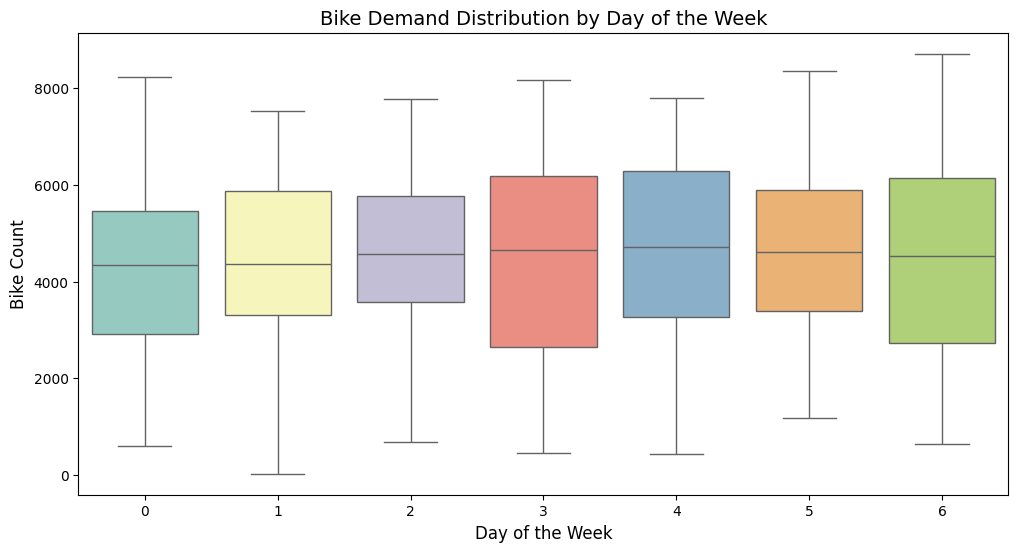

In [9]:
# Weekday vs Bike Demand

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_day, x='weekday', y='cnt', palette='Set3')

plt.title('Bike Demand Distribution by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Bike Count', fontsize=12)
plt.show()


### Observations
. The median bike demand is fairly similar across all days, indicating that bike rentals remain consistent throughout the week.<br>
. Thursday (4) and Wednesday (3) have slightly higher median bike counts, suggesting increased commuting activity during mid-week.<br>
. Sunday (0) has the lowest median demand, reflecting reduced commuting and more leisure-based travel.<br>
. The interquartile range (IQR) is similar for most days, meaning the variability in bike demand is consistent throughout the week.<br>
. All weekdays show a wide spread between minimum and maximum values, indicating that factors such as weather, holidays, and seasons influence demand in addition to the day of the week.

C:\Users\sarth\AppData\Local\Temp\ipykernel_42072\1633425042.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_day, x='season', y='cnt', palette='Set3')


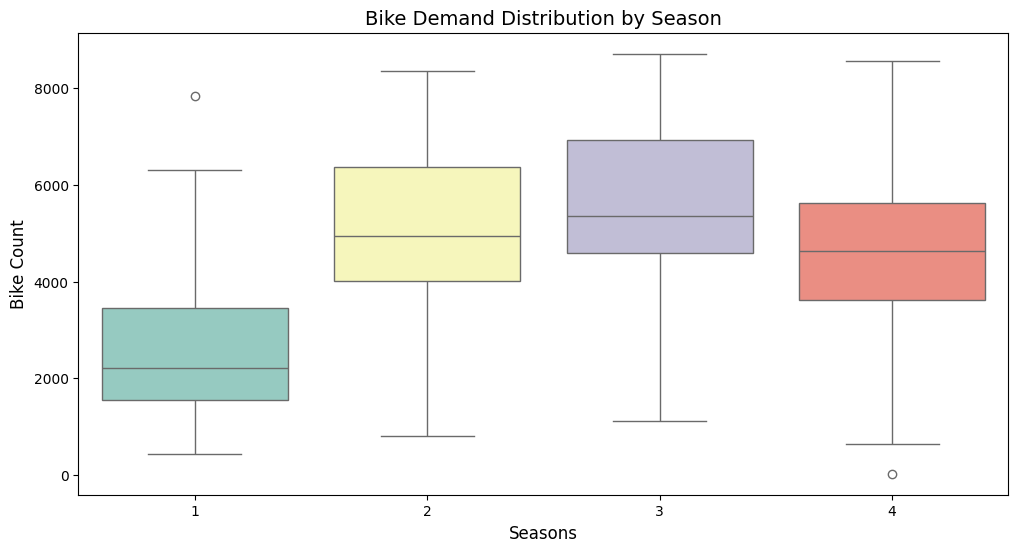

In [10]:
# Season vs Bike Demand

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_day, x='season', y='cnt', palette='Set3')

plt.title('Bike Demand Distribution by Season', fontsize=14)
plt.xlabel('Seasons', fontsize=12)
plt.ylabel('Bike Count', fontsize=12)
plt.show()


### Analysis: Bike Demand Distribution by Season

#### Season Mapping (UCI Bike Sharing Dataset):

1 = Spring
2 = Summer
3 = Fall
4 = Winter

#### Observations

Spring (Season 1) has the lowest median bike demand, indicating fewer bike rentals during this season.<br>
Fall (Season 3) shows the highest median demand, suggesting that pleasant weather encourages more bike usage.<br>
Summer (Season 2) also has high bike demand, slightly lower than Fall.<br>
Winter (Season 4) experiences moderate demand, lower than Summer and Fall but considerably higher than Spring.<br>
Fall and Summer have wider interquartile ranges (IQRs), indicating greater variability in bike rentals across different days.<br>
A few outliers are present, representing days with unusually high or low rental counts, likely due to special events or extreme weather.

C:\Users\sarth\AppData\Local\Temp\ipykernel_42072\952067647.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_day, x='weathersit', y='cnt', palette='Set3')


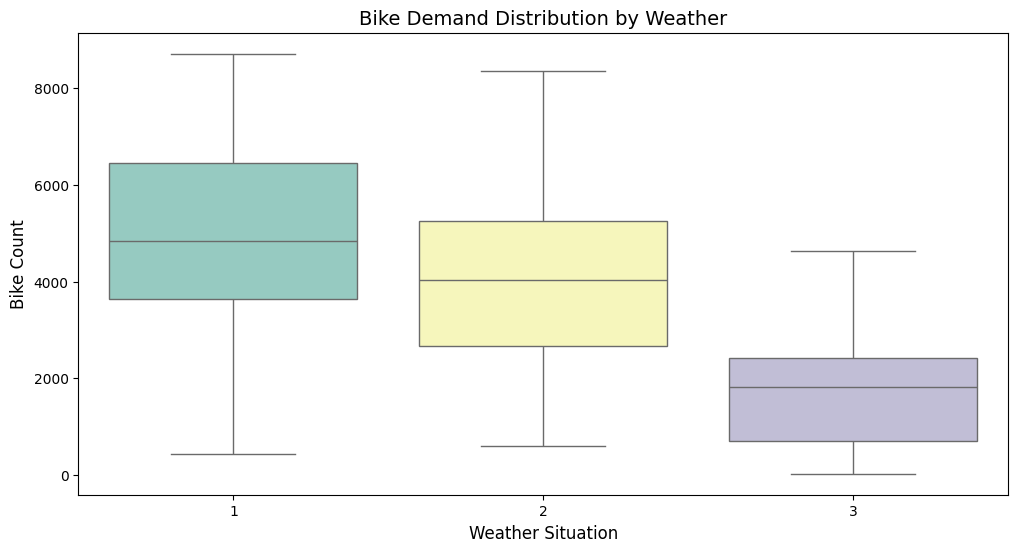

In [11]:
# Weather vs Bike Demand

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_day, x='weathersit', y='cnt', palette='Set3')

plt.title('Bike Demand Distribution by Weather', fontsize=14)
plt.xlabel('Weather Situation', fontsize=12)
plt.ylabel('Bike Count', fontsize=12)
plt.show()


### Observartion

1 = Clear
2 = Mist
3 = Light Rain/Snow
4 = Heavy Rain

The dataset contains observations for weather categories 1 (Clear), 2 (Mist/Cloudy), and 3 (Light Rain/Snow).
<br>
 No records are present for weather category 4 (Heavy Rain/Thunderstorm), indicating that such extreme weather conditions did not occur or were not captured during data collection.
 <br>
 Bike demand decreases as weather conditions worsen.

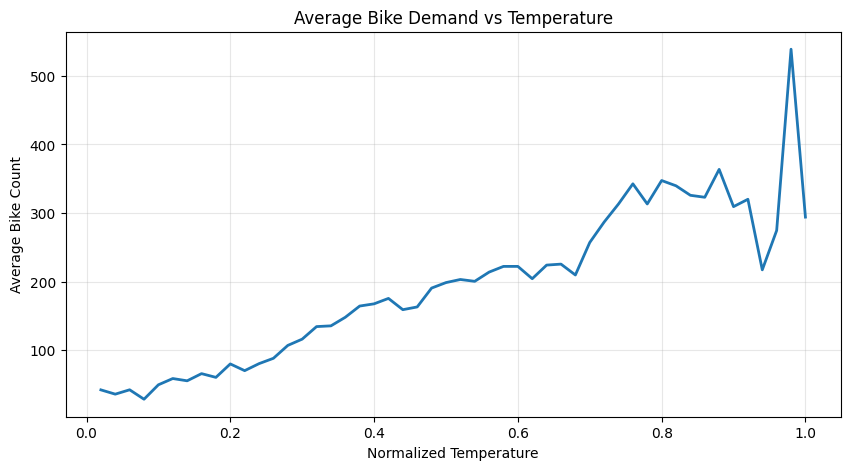

In [12]:
# Temperature vs Bike Demand

temp_demand = df_hour.groupby("temp")["cnt"].mean()

plt.figure(figsize=(10,5))

plt.plot(temp_demand.index,
         temp_demand.values,
         linewidth=2)

plt.title("Average Bike Demand vs Temperature")
plt.xlabel("Normalized Temperature")
plt.ylabel("Average Bike Count")
plt.grid(alpha=0.3)

plt.show()

### Observations

The temp values are continuous normalized values. Some temperature values occur only 1 or 2 times in the dataset.
<br>
For example,<br>
Temp	   Number_of_Records	   Avg_Demand<br>
0.98	      2	                 540<br>
0.99	      1	                 295<br>
<br>
Since there are very few observations at those temperatures, the average fluctuates a lot, producing those spikes.
#### Better Approach: Bin the Temperature
Instead of plotting every unique temperature value, divide temperatures into bins and compute the average demand in each bin.

C:\Users\sarth\AppData\Local\Temp\ipykernel_42072\876807537.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_avg = df_hour.groupby("temp_bin")["cnt"].mean()


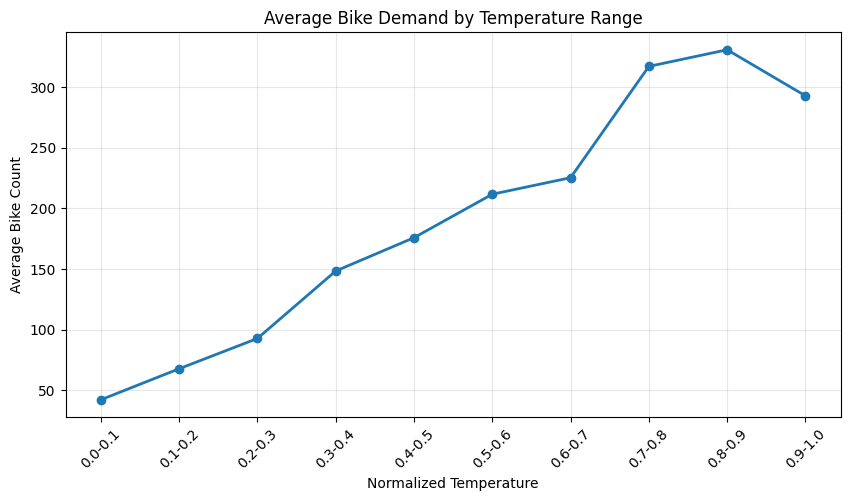

In [13]:
# Create 10 equal-width temperature bins
df_hour["temp_bin"] = pd.cut(df_hour["temp"], bins=10)

# Average demand in each bin
temp_avg = df_hour.groupby("temp_bin")["cnt"].mean()

plt.figure(figsize=(10,5))

plt.plot(range(len(temp_avg)),
         temp_avg.values,
         marker='o',
         linewidth=2)

plt.xticks(range(len(temp_avg)),
           [f"{interval.left:.1f}-{interval.right:.1f}" for interval in temp_avg.index],
           rotation=45)

plt.title("Average Bike Demand by Temperature Range")
plt.xlabel("Normalized Temperature")
plt.ylabel("Average Bike Count")
plt.grid(alpha=0.3)

plt.show()

#### Observation

Bike demand generally increases with temperature, reaching its peak during warm weather (0.8–0.9 normalized temperature).<br> Demand decreases slightly at the highest temperature range, indicating that extremely hot conditions may discourage some users from renting bikes.<br> Therefore, temperature is an important predictor of bike demand and should be retained as a key feature in the forecasting model.

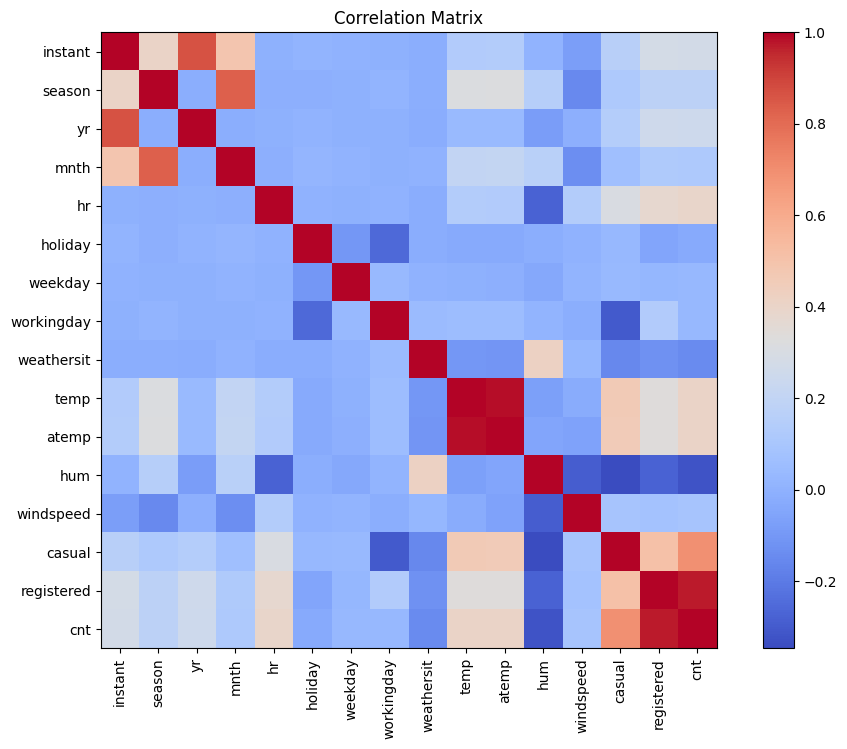

In [14]:
# Correlation Matrix

corr = df_hour.corr(numeric_only=True)

plt.figure(figsize=(12,8))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

### Correlation Matrix Analysis

Bike demand analysis indicates that registered and casual user metrics serve as primary demand predictors, though they act as data leakage, while temp and atemp exhibit strong positive correlations with higher rentals. Conversely, weathersit and humidity function as key demand inhibitors, with high humidity and poor weather significantly reducing bike usage.